In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## 지수평활법

In [45]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)

ar = np.array([1, 0, 0, 0])                 # AR 계수 (AR계수가 없는 상태)
ma = np.array([1, 0.9, 0.3, 0.5])           # MA 계수 (MA계수가 3개이므로 MA(3))

ARMA_process = ArmaProcess(ar, ma).generate_sample(nsample=1000)

# 날짜 생성: 2020-01-01부터 하루씩 증가, 길이는 1000
dates = pd.date_range(start="2020-01-01", periods=1000, freq="D")

data = pd.DataFrame({ 
                     "date" : dates,
                     "score" : ARMA_process
                    })
data

,date,score
0,2020-01-01,0.496714
1,2020-01-02,0.308778
2,2020-01-03,0.672265
3,2020-01-04,2.312827
4,2020-01-05,1.261748
...,...,...
995,2022-09-22,-1.510742
996,2022-09-23,0.903218
997,2022-09-24,1.673621
998,2022-09-25,0.404335


In [46]:
data = data.set_index("date").copy()
data

,score
date,
2020-01-01,0.496714
2020-01-02,0.308778
2020-01-03,0.672265
2020-01-04,2.312827
2020-01-05,1.261748
...,...
2022-09-22,-1.510742
2022-09-23,0.903218
2022-09-24,1.673621


In [47]:
train = data.iloc[:700, :]
test = data.iloc[700:, :]

In [48]:
# 1. 단순 지수평활법                         ==> 추세와 계절성이 없는
# 2. 홀트 지수평활법 (2중 지수평활법)        ==> 추세가 있고 계절성이 없는
# 3. 홀트-윈터 지수평활법 (3중 지수평활법)   ==> 추세도 있고 계절성도 있고

In [49]:
### 단순 지수평활법
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(
                           train["score"]           ### 훈련데이터
                           ).fit()
model.summary()

Dep. Variable:,score,No. Observations:,700
Model:,SimpleExpSmoothing,SSE,1140.144
Optimized:,True,AIC,345.480
Trend:,None,BIC,354.583
Seasonal:,None,AICC,345.538
Seasonal Periods:,None,Date:,"Sat, 06 Sep 2025"
Box-Cox:,False,Time:,21:59:44
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.7014116,alpha,True
initial_level,0.5072499,l.0,True


In [50]:
### 예측
pred = model.forecast(steps=len(test))
pred

2021-12-01    0.214905
2021-12-02    0.214905
2021-12-03    0.214905
2021-12-04    0.214905
2021-12-05    0.214905
                ...   
2022-09-22    0.214905
2022-09-23    0.214905
2022-09-24    0.214905
2022-09-25    0.214905
2022-09-26    0.214905
Freq: D, Length: 300, dtype: float64

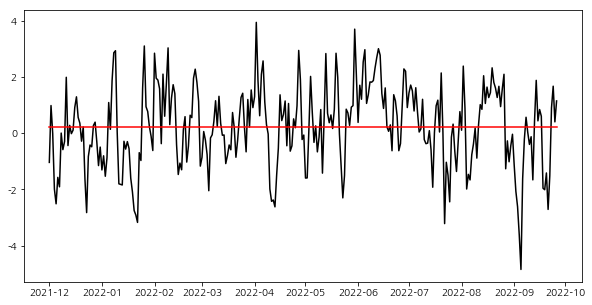

In [51]:
### 예측시각화

plt.figure(figsize=(10,5))

plt.plot(test["score"], color="black", label="Real")
plt.plot(pred, color="red", label="Predict")

plt.show()

In [52]:
### 홀트 지수평활법 (2중 지수평활법)
from statsmodels.tsa.holtwinters import Holt

model = Holt(
             train["score"],           ### 훈련데이터
             initial_level=None,        # 초기 수준값
             initial_trend=None         # 초기 추세값
             ).fit()

model.summary()

Dep. Variable:,score,No. Observations:,700
Model:,Holt,SSE,1140.143
Optimized:,True,AIC,349.480
Trend:,Additive,BIC,367.685
Seasonal:,None,AICC,349.601
Seasonal Periods:,None,Date:,"Sat, 06 Sep 2025"
Box-Cox:,False,Time:,21:59:45
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.7014195,alpha,True
smoothing_trend,7.6599e-19,beta,True


In [53]:
### 예측
pred = model.forecast(steps=len(test))
pred

2021-12-01    0.214313
2021-12-02    0.213894
2021-12-03    0.213475
2021-12-04    0.213056
2021-12-05    0.212637
                ...   
2022-09-22    0.090720
2022-09-23    0.090301
2022-09-24    0.089882
2022-09-25    0.089463
2022-09-26    0.089044
Freq: D, Length: 300, dtype: float64

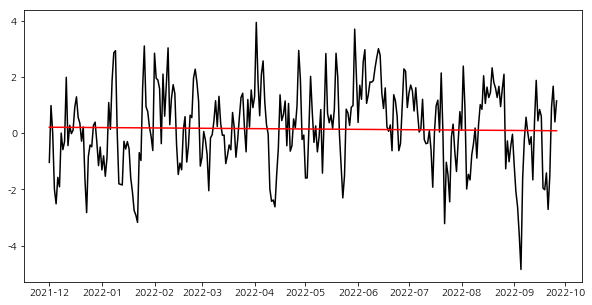

In [54]:
### 예측시각화

plt.figure(figsize=(10,5))

plt.plot(test["score"], color="black", label="Real")
plt.plot(pred, color="red", label="Predict")

plt.show()

In [55]:
### 홀트-윈터 지수평활법 (3중 지수평활법)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
                             train["score"],               ## 훈련 데이터
                             trend="add",                   # 추세 종류(가법형(add), 승법형(mul))
                             seasonal="add",                # 계절성 종류(가법형(add), 승법형(mul))
                             seasonal_periods=12            # 계절성 주기
                             ).fit()
model.summary()

Dep. Variable:,score,No. Observations:,700
Model:,ExponentialSmoothing,SSE,1115.679
Optimized:,True,AIC,358.297
Trend:,Additive,BIC,431.114
Seasonal:,Additive,AICC,359.301
Seasonal Periods:,12,Date:,"Sat, 06 Sep 2025"
Box-Cox:,False,Time:,21:59:46
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.7024378,alpha,True
smoothing_trend,2.538e-09,beta,True


In [56]:
### 예측
pred = model.forecast(steps=len(test))
pred

2021-12-01    0.079252
2021-12-02    0.406564
2021-12-03    0.720951
2021-12-04    0.494715
2021-12-05    0.447031
                ...   
2022-09-22    0.258703
2022-09-23    0.396978
2022-09-24    0.106306
2022-09-25    0.075357
2022-09-26    0.178065
Freq: D, Length: 300, dtype: float64

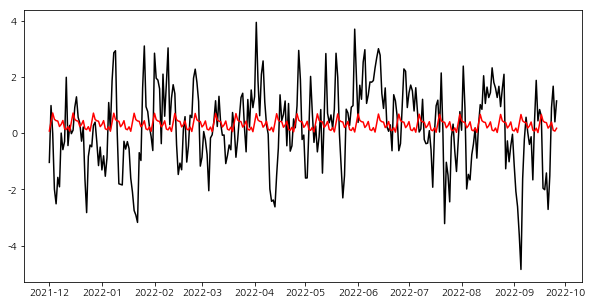

In [57]:
### 예측시각화

plt.figure(figsize=(10,5))

plt.plot(test["score"], color="black", label="Real")
plt.plot(pred, color="red", label="Predict")

plt.show()

In [ ]:
## 평균 예측

In [ ]:
## 나이브 예측 등등 ...